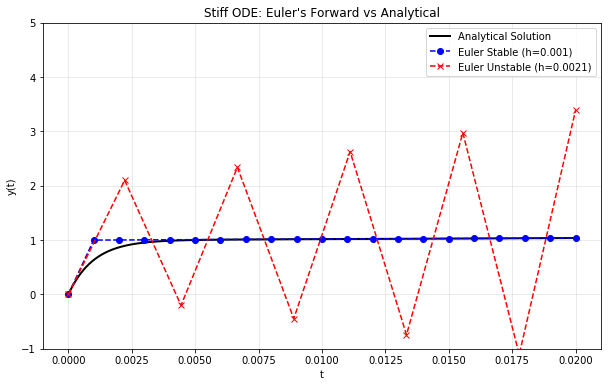

In [2]:
import numpy as np
import matplotlib.pyplot as plt


def f(t, y):
    return -1000*y + 3000 - 2000*np.exp(-t)

def analytical(t):
    return 3 - 0.998*np.exp(-1000*t) - 2.002*np.exp(-t)


t_end = 0.02  
h_stable = 0.001
h_unstable = 0.0021

def solve_euler(h, t_max):
    steps = int(t_max / h)
    t_vals = np.linspace(0, t_max, steps + 1)
    y_vals = np.zeros(steps + 1)
    y_vals[0] = 0 
    
    for i in range(steps):
        y_vals[i+1] = y_vals[i] + h * f(t_vals[i], y_vals[i])
    return t_vals, y_vals


t_s, y_s = solve_euler(h_stable, t_end)
t_u, y_u = solve_euler(h_unstable, t_end)
t_fine = np.linspace(0, t_end, 1000)
y_exact = analytical(t_fine)


plt.figure(figsize=(10, 6))
plt.plot(t_fine, y_exact, 'k-', label='Analytical Solution', linewidth=2)
plt.plot(t_s, y_s, 'bo--', label=f'Euler Stable (h={h_stable})')
plt.plot(t_u, y_u, 'rx--', label=f'Euler Unstable (h={h_unstable})')

plt.ylim(-1, 5) 
plt.title("Stiff ODE: Euler's Forward vs Analytical")
plt.xlabel("t")
plt.ylabel("y(t)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()